# No-control random-initialization learning, then controlled evaluation

This notebook learns the graph identifier from many **no-control** rollouts, each started from a fresh bounded random initial state.  
Each training repeat uses **one campaign only** for data collection.  
After learning, the **final learned model** is evaluated under control exactly as before:
- learned control
- oracle control
- no control

A dedicated sanity-check cell is included to inspect the training initial states and their coverage of the opinion range.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

def get_dir_n_levels_up(path, n):
    for _ in range(n):
        path = os.path.dirname(path)
    return path

proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 3)
if proj_root not in sys.path:
    sys.path.append(proj_root)

print("proj_root:", proj_root)

proj_root: d:\Work\repos\RL\unknown_graph_networks


In [3]:
# =========================================================
# Imports + helpers
# =========================================================

import contextlib
import io
import time
from typing import Any
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)
import copy


# from opinion_dynamics.identify_freeprop import (
#     GraphIdentifierEnv,
#     pairs_from_intermediate,
#     train_graph_identifier,
# )

from opinion_dynamics.identify_nonlinear import (
    GraphIdentifierEnv,
    pairs_from_intermediate,
    train_graph_identifier,
)

from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import centrality_based_continuous_control
from opinion_dynamics.experiments.rollouts import (
    rollout_with_v,
    rollout_with_v_intermediate,
    make_env_with_dynamics,
)
from opinion_dynamics.experiments.plots import (
    plot_impulse_node_trajectories,
    show_matrix_with_cell_grid,
    concat_intermediate,
)
from opinion_dynamics.experiments.metrics import graph_sanity


def _maybe_copy(v):
    if v is None:
        return None
    if isinstance(v, np.ndarray):
        return np.array(v, copy=True)
    try:
        return np.array(v, copy=True)
    except Exception:
        return v


def _env_template_kwargs_full(env, fallback_seed: int | None = None) -> dict[str, Any]:
    kwargs = dict(
        connectivity_matrix=np.array(env.connectivity_matrix, copy=True),
        num_agents=int(env.num_agents),
        max_u=np.array(env.max_u, copy=True),
        desired_opinion=float(env.desired_opinion),
        t_campaign=float(env.t_campaign),
        t_s=float(env.t_s),
        dynamics_model=str(getattr(env, "dynamics_model", "laplacian")),
        control_resistance=np.array(
            getattr(env, "control_resistance", np.zeros(env.num_agents)),
            copy=True,
        ),
        max_steps=int(getattr(env, "max_steps", 10_000)),
        opinion_end_tolerance=float(getattr(env, "opinion_end_tolerance", 0.01)),
        control_beta=float(getattr(env, "control_beta", 0.4)),
        normalize_reward=bool(getattr(env, "normalize_reward", False)),
        terminal_reward=float(getattr(env, "terminal_reward", 0.0)),
        terminate_when_converged=bool(getattr(env, "terminate_when_converged", True)),
        seed=int(getattr(env, "seed", fallback_seed))
        if getattr(env, "seed", None) is not None or fallback_seed is not None
        else None,
    )

    # Preserve dynamics-specific parameters when recreating fresh envs.
    for name in [
        "fj_lambda",
        "fj_prejudice",
        "hk_epsilon",
        "hk_include_self",
        "nonlinear_beta",
        "repulsion_epsilon",
        "repulsion_strength",
    ]:
        if hasattr(env, name):
            val = getattr(env, name)
            if val is not None:
                kwargs[name] = _maybe_copy(val)

    return kwargs


def _fresh_env_from_template(
    env_template,
    *,
    repeat_seed: int | None,
    initial_opinions: np.ndarray | None = None,
):
    EnvCls = env_template.__class__
    kwargs = _env_template_kwargs_full(env_template, fallback_seed=repeat_seed)
    kwargs["seed"] = repeat_seed
    if initial_opinions is not None:
        kwargs["initial_opinions"] = np.array(initial_opinions, copy=True)
    env = EnvCls(**kwargs)
    return env, kwargs


def sample_init_opinions(
    N: int,
    rng: np.random.Generator,
    mode: str = "uniform",
    low: float = 0.01,
    high: float = 0.99,
) -> np.ndarray:
    if mode == "permuted_linspace":
        x0 = np.linspace(low, high, N, dtype=float)
        rng.shuffle(x0)
        return x0
    if mode == "uniform":
        return rng.uniform(low, high, size=N).astype(float)
    raise ValueError(f"Unknown init_mode: {mode}")


def summarize_training_inits(x0_list: np.ndarray) -> pd.DataFrame:
    rows = []
    for r in range(x0_list.shape[0]):
        x = np.asarray(x0_list[r], dtype=float)
        rows.append(
            dict(
                repeat=r,
                min=float(x.min()),
                q10=float(np.quantile(x, 0.10)),
                q25=float(np.quantile(x, 0.25)),
                median=float(np.median(x)),
                q75=float(np.quantile(x, 0.75)),
                q90=float(np.quantile(x, 0.90)),
                max=float(x.max()),
                mean=float(x.mean()),
                std=float(x.std()),
                range=float(x.max() - x.min()),
            )
        )
    return pd.DataFrame(rows)

def waterfill_from_scores(
    scores: np.ndarray,
    max_u: np.ndarray,
    beta: float,
) -> np.ndarray:
    """
    Greedy water-filling / top-score allocation with per-node caps.
    """
    scores = np.asarray(scores, dtype=float)
    max_u = np.asarray(max_u, dtype=float)
    u = np.zeros_like(max_u, dtype=float)

    remaining = min(float(beta), float(max_u.sum()))
    order = np.argsort(-scores)

    for idx in order:
        if remaining <= 1e-12:
            break
        alloc = min(float(max_u[idx]), remaining)
        u[idx] = alloc
        remaining -= alloc

    return u


def uniform_budget_action(max_u: np.ndarray, beta: float) -> np.ndarray:
    """
    Split budget as uniformly as possible across all nodes, while respecting max_u.
    """
    max_u = np.asarray(max_u, dtype=float)
    u = np.zeros_like(max_u, dtype=float)

    remaining = min(float(beta), float(max_u.sum()))
    active = np.ones(max_u.shape[0], dtype=bool)

    while remaining > 1e-12 and active.any():
        share = remaining / active.sum()
        capped = active & (max_u <= share + 1e-12)

        if capped.any():
            u[capped] = max_u[capped]
            remaining -= float(max_u[capped].sum())
            active[capped] = False
        else:
            u[active] = share
            remaining = 0.0

    return u


def centrality_budget_action_from_state(
    x: np.ndarray,
    *,
    v: np.ndarray,
    max_u: np.ndarray,
    beta: float,
    desired_opinion: float,
) -> np.ndarray:
    """
    Centrality-based campaign allocation using current state x and centrality vector v.
    """
    x = np.asarray(x, dtype=float)
    v = np.asarray(v, dtype=float)
    scores = v * np.abs(float(desired_opinion) - x)
    return waterfill_from_scores(scores, max_u=np.asarray(max_u, dtype=float), beta=float(beta))


def apply_impulse_control(
    x: np.ndarray,
    u: np.ndarray,
    desired_opinion: float,
) -> np.ndarray:
    """
    Campaign impulse:
        x_ctrl = u * desired_opinion + (1 - u) * x
    """
    x = np.asarray(x, dtype=float)
    u = np.asarray(u, dtype=float)
    d = float(desired_opinion)
    return u * d + (1.0 - u) * x


def effective_adjacency_from_model_state(
    model,
    x: np.ndarray,
    *,
    device: str = "cpu",
) -> np.ndarray:
    """
    Build a state-dependent effective adjacency by combining the learned static
    adjacency A_hat with the learned nonlinear gate alpha(x_i, x_j), then
    row-normalizing the result.

    A_eff(x) = row_normalize( A_hat ⊙ alpha(x) )
    """
    mdl = model.to(device).eval()
    x_arr = np.asarray(x, dtype=float)

    with torch.no_grad():
        x_t = torch.tensor(x_arr[None, :], dtype=torch.float32, device=device)
        A_hat = mdl.A_hat()  # (N, N)

        xi = x_t.unsqueeze(2)  # (1, N, 1)
        xj = x_t.unsqueeze(1)  # (1, 1, N)
        alpha = mdl.alpha(xi, xj).squeeze(0)  # (N, N)

        A_eff = A_hat * alpha

        if getattr(mdl, "zero_diag", False):
            A_eff = A_eff * mdl._diag_mask

        rs = A_eff.sum(dim=1, keepdim=True)
        rs = torch.where(rs > 0, rs, torch.ones_like(rs))
        A_eff = A_eff / rs

    return A_eff.detach().cpu().numpy()


def effective_centrality_from_model_state(
    model,
    x: np.ndarray,
    *,
    device: str = "cpu",
) -> tuple[np.ndarray, np.ndarray]:
    """
    Return (A_eff(x), v_eff(x)) where v_eff is the centrality computed from the
    derived state-dependent effective adjacency.
    """
    A_eff = effective_adjacency_from_model_state(model, x, device=device)
    v_eff = compute_eigenvector_centrality(compute_laplacian(A_eff))
    return A_eff, np.asarray(v_eff, dtype=float)



def model_one_step_mae_np(model, X: np.ndarray, Y: np.ndarray, *, device: str = "cpu") -> float:
    """MAE of model.predict_next(X) against Y."""
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    if X.size == 0:
        return float("nan")
    mdl = model.to(device).eval()
    with torch.no_grad():
        Xt = torch.tensor(X, dtype=torch.float32, device=device)
        Yt = torch.tensor(Y, dtype=torch.float32, device=device)
        Yhat = mdl.predict_next(Xt)
        return float(torch.mean(torch.abs(Yhat - Yt)).detach().cpu().item())


def identity_one_step_mae_np(X: np.ndarray, Y: np.ndarray) -> float:
    """MAE of the trivial one-step predictor x_next_hat = x."""
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    if X.size == 0:
        return float("nan")
    return float(np.mean(np.abs(Y - X)))


def action_support_jaccard(u_a: np.ndarray, u_b: np.ndarray, *, tol: float = 1e-12) -> float:
    sa = set(np.flatnonzero(np.asarray(u_a) > tol).tolist())
    sb = set(np.flatnonzero(np.asarray(u_b) > tol).tolist())
    if not sa and not sb:
        return 1.0
    return float(len(sa & sb) / max(len(sa | sb), 1))


def action_l1_mean(actions_a: np.ndarray, actions_b: np.ndarray) -> float:
    A = np.asarray(actions_a, dtype=float)
    B = np.asarray(actions_b, dtype=float)
    T = min(A.shape[0], B.shape[0])
    if T == 0:
        return float("nan")
    return float(np.mean(np.sum(np.abs(A[:T] - B[:T]), axis=1)))


def rollout_with_model_derived_control_intermediate(
    env,
    model,
    x0: np.ndarray,
    num_campaigns_total: int,
    B_campaign: float,
    *,
    device: str = "cpu",
):
    """
    Roll out the TRUE environment using a learned state-dependent control policy.

    At each campaign boundary:
      1) derive A_eff(x_k) from the learned model
      2) compute v_eff(x_k) from A_eff(x_k)
      3) allocate control using that v_eff(x_k)

    This uses the true environment for propagation, not the learned model.
    """
    x, _ = env.reset()

    mdl = copy.deepcopy(model).to(device).eval()

    states = [np.asarray(x, dtype=float).copy()]
    actions = []
    rewards = []
    intermediate_states_list = []
    intermediate_times_list = []
    effective_adjacencies = []
    effective_centralities = []

    dt = float(getattr(env, "t_s", 1.0))
    desired_opinion = float(getattr(env, "desired_opinion", 1.0))
    max_u = np.asarray(getattr(env, "max_u", np.ones_like(states[0])), dtype=float)

    for _k in range(int(num_campaigns_total)):
        x_curr = np.asarray(states[-1], dtype=float)

        A_eff, v_eff = effective_centrality_from_model_state(mdl, x_curr, device=device)
        u = centrality_budget_action_from_state(
            x_curr,
            v=v_eff,
            max_u=max_u,
            beta=B_campaign,
            desired_opinion=desired_opinion,
        )

        x_next, r, done, trunc, info = env.step(np.asarray(u, dtype=float))

        effective_adjacencies.append(np.asarray(A_eff, dtype=float))
        effective_centralities.append(np.asarray(v_eff, dtype=float))
        actions.append(np.asarray(u, dtype=float).copy())
        rewards.append(float(r))
        states.append(np.asarray(x_next, dtype=float).copy())

        inter = info.get("intermediate_states", None)
        if inter is None:
            intermediate_states_list.append(None)
            intermediate_times_list.append(None)
        else:
            inter_arr = np.asarray(inter, dtype=float)
            intermediate_states_list.append(inter_arr)
            intermediate_times_list.append(dt * np.arange(inter_arr.shape[0], dtype=float))

        if done or trunc:
            break

    return {
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "intermediate_times_list": intermediate_times_list,
        "effective_adjacencies": effective_adjacencies,
        "effective_centralities": effective_centralities,
    }


def rollout_with_policy_intermediate(
    env,
    x0: np.ndarray,
    num_campaigns_total: int,
    action_fn,
):
    """
    Roll out the TRUE environment using an external policy action_fn(x_current).
    """
    x, _ = env.reset()

    states = [np.asarray(x, dtype=float).copy()]
    actions = []
    rewards = []
    intermediate_states_list = []
    intermediate_times_list = []

    dt = float(getattr(env, "t_s", 1.0))

    for _k in range(int(num_campaigns_total)):
        x_curr = np.asarray(states[-1], dtype=float)
        u = np.asarray(action_fn(x_curr), dtype=float)

        x_next, r, done, trunc, info = env.step(u)

        actions.append(np.array(u, copy=True))
        rewards.append(float(r))
        states.append(np.asarray(x_next, dtype=float).copy())

        inter = info.get("intermediate_states", None)
        if inter is None:
            intermediate_states_list.append(None)
            intermediate_times_list.append(None)
        else:
            inter_arr = np.asarray(inter, dtype=float)
            intermediate_states_list.append(inter_arr)
            intermediate_times_list.append(dt * np.arange(inter_arr.shape[0], dtype=float))

        if done or trunc:
            break

    return {
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "intermediate_times_list": intermediate_times_list,
    }


def rollout_with_uniform_intermediate(
    env,
    x0: np.ndarray,
    num_campaigns_total: int,
    B_campaign: float,
):
    max_u = np.asarray(env.max_u, dtype=float)
    return rollout_with_policy_intermediate(
        env,
        x0,
        num_campaigns_total,
        action_fn=lambda x: uniform_budget_action(max_u=max_u, beta=B_campaign),
    )



def build_augmented_campaign_trajectory(
    states_boundary: np.ndarray,
    actions: np.ndarray,
    intermediate_states_list,
    *,
    desired_opinion: float,
    dt: float,
    t_campaign: float | None = None,
    eps_t: float = 1e-6,
):
    """
    Build a fine-grained trajectory that explicitly includes, for each campaign:
      1) boundary state x_k
      2) immediate post-impulse state x_k^ctrl
      3) propagation substeps returned in intermediate_states_list

    This makes jumps caused by the campaign impulse explicit and avoids the
    misleading appearance that different policies "start" from different points.
    """
    states_boundary = np.asarray(states_boundary, dtype=float)
    actions = np.asarray(actions, dtype=float)

    if states_boundary.ndim != 2:
        raise ValueError("states_boundary must have shape (K+1, N).")

    X_parts = [states_boundary[0][None, :].copy()]
    T_parts = [np.array([0.0], dtype=float)]

    campaign_duration = float(dt if t_campaign is None else t_campaign)
    num_campaigns = min(len(actions), len(intermediate_states_list), max(states_boundary.shape[0] - 1, 0))

    for k in range(num_campaigns):
        current_time = k * campaign_duration
        x_pre = np.asarray(states_boundary[k], dtype=float)
        u_k = np.asarray(actions[k], dtype=float)
        x_ctrl = apply_impulse_control(x_pre, u_k, desired_opinion=float(desired_opinion))

        # Explicit immediate post-impulse point.
        X_parts.append(x_ctrl[None, :].copy())
        T_parts.append(np.array([current_time + eps_t], dtype=float))

        inter = intermediate_states_list[k]
        if inter is not None:
            inter_arr = np.asarray(inter, dtype=float)

            # If the env already included x_ctrl as the first intermediate state,
            # drop that duplicate because we just inserted it explicitly.
            if inter_arr.ndim == 2 and inter_arr.shape[0] > 0:
                if np.max(np.abs(inter_arr[0] - x_ctrl)) <= 1e-8:
                    inter_arr = inter_arr[1:]

            if inter_arr.ndim == 2 and inter_arr.shape[0] > 0:
                t_inter = current_time + dt * np.arange(1, inter_arr.shape[0] + 1, dtype=float)
                X_parts.append(inter_arr)
                T_parts.append(t_inter)

    X = np.vstack(X_parts)
    T = np.concatenate(T_parts)
    return X, T


def rollout_identifier_model_with_policy(
    model,
    env_template,
    x0: np.ndarray,
    num_campaigns_total: int,
    B_campaign: float,
    *,
    policy: str = "centrality",
    v: np.ndarray | None = None,
    device: str = "cpu",
):
    """
    Roll out the LEARNED model only:
      - apply campaign impulse in state space
      - then evolve using model.predict_next for the substeps inside each campaign
    """
    mdl = copy.deepcopy(model).to(device).eval()

    x = np.asarray(x0, dtype=float).copy()
    N = x.shape[0]
    desired_opinion = float(getattr(env_template, "desired_opinion", 1.0))
    max_u = np.asarray(getattr(env_template, "max_u", np.ones(N)), dtype=float)
    dt = float(getattr(env_template, "t_s", 1.0))
    t_campaign = float(getattr(env_template, "t_campaign", dt))
    steps_per_campaign = max(1, int(round(t_campaign / dt)))

    states = [x.copy()]
    actions = []
    intermediate_states_list = []
    intermediate_times_list = []

    for _k in range(int(num_campaigns_total)):
        if policy == "centrality":
            if v is None:
                raise ValueError("policy='centrality' requires a centrality vector v.")
            u = centrality_budget_action_from_state(
                x,
                v=np.asarray(v, dtype=float),
                max_u=max_u,
                beta=B_campaign,
                desired_opinion=desired_opinion,
            )
        elif policy == "uniform":
            u = uniform_budget_action(max_u=max_u, beta=B_campaign)
        elif policy == "none":
            u = np.zeros(N, dtype=float)
        else:
            raise ValueError(f"Unknown policy: {policy}")

        x_ctrl = apply_impulse_control(x, u, desired_opinion=desired_opinion)

        campaign_states = [x_ctrl.copy()]
        xt = torch.tensor(x_ctrl[None, :], dtype=torch.float32, device=device)

        with torch.no_grad():
            for _ in range(steps_per_campaign):
                xt = mdl.predict_next(xt)
                x_sub = xt[0].detach().cpu().numpy()
                x_sub = np.clip(x_sub, 0.0, 1.0)
                campaign_states.append(x_sub.copy())

        x = campaign_states[-1].copy()
        states.append(x.copy())
        actions.append(u.copy())
        intermediate_states_list.append(np.asarray(campaign_states, dtype=float))
        intermediate_times_list.append(dt * np.arange(len(campaign_states), dtype=float))

    return {
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "intermediate_times_list": intermediate_times_list,
    }


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_117404\1263436835.py:12: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [4]:
# =========================================================
# Global experiment configuration
# Edit these here and the later cells will reuse them consistently.
# =========================================================

SEEDS = range(10)
SEED_TO_PLOT = 3

B_CAMPAIGN = 1.0
LEARN_NUM_CAMPAIGNS = 1
EVAL_NUM_CAMPAIGNS = 5
NUM_REPEATS = 100

# Fair evaluation convention:
# Controlled policies act at campaign 0 from the same x0_eval.
# The old oracle helper used a passive first campaign by default; do not rely on that default.
EVAL_ZERO_FIRST_CAMPAIGN = False

# Data/init settings
INIT_MODE = "uniform"

# Fit settings for the nonlinear identifier
FIT_MAX_STEPS = 2_000
FIT_CHECK_EVERY = 1_000

# Kept as a global for consistency with other notebooks.
# In THIS single-campaign no-control notebook it is effectively unused,
# because the learning loop already fits once per repeat after collecting
# the one no-control rollout.
UPDATE_A_EACH_CAMPAIGN = False

DYNAMICS_LIST = [
    "laplacian",
    "coca",
    # "friedkinjohnsen",
    "hegselmannkrause",
    # "nonlinearinfluence",
    # "repulsion",
]

FIT_BY_DYNAMICS = {
    "laplacian": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=1e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "coca": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=512,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "friedkinjohnsen": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "hegselmannkrause": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "nonlinearinfluence": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
}

# Optional identifier overrides; threaded into GraphIdentifierEnv(...)
IDENTIFIER_KW = {}


In [5]:
# =========================================================
# Core experiment:
# learn from MANY no-control, one-campaign rollouts
# with fresh bounded random initial states.
# Then evaluate the FINAL learned model under control.
# =========================================================

def run_repeated_nocontrol_singlecampaign_id_on_env(
    env_template,
    *,
    num_repeats=100,
    init_mode="uniform",
    init_low=0.01,
    init_high=0.99,
    init_seed_base: int = 12345,
    learn_num_campaigns=1,
    eval_num_campaigns=5,
    B_campaign=1.0,
    lr=1e-3,
    l2_lambda=0.0,
    device="cpu",
    suppress_fit_logs=True,
    fit_max_steps=50_000,
    fit_mae_stop=1e-3,
    fit_batch_size=64,
    fit_check_every=200,
    identifier_kwargs=None,
    repeat_seed_stride: int = 10_000,
    eval_seed_offset: int = 999_999,
):
    """
    Learning phase:
      - same graph topology
      - fresh random x0 each repeat
      - NO CONTROL only
      - collect data from learn_num_campaigns (default: 1) campaign rollouts
      - accumulate transition pairs and refit after each repeat

    Evaluation phase:
      - fixed evaluation x0
      - run eval_num_campaigns with:
          * learned control (using v_hat from A_hat)
          * oracle control (using v_true)
          * no control
    """
    N = int(env_template.num_agents)
    A_true = np.asarray(env_template.connectivity_matrix, dtype=float)
    v_true = compute_eigenvector_centrality(compute_laplacian(A_true))
    v_flat = np.full(N, 1.0 / max(N, 1), dtype=float)  # deviation-only top-k baseline

    base_seed = int(getattr(env_template, "seed", 0) or 0)

    gi = GraphIdentifierEnv(
        N=N,
        s=float(env_template.t_s),
        l2_lambda=l2_lambda,
        zero_diag=True,
        **({} if identifier_kwargs is None else identifier_kwargs),
    )

    buf_x: list[np.ndarray] = []
    buf_y: list[np.ndarray] = []
    repeat_rows: list[dict[str, Any]] = []
    repeat_artifacts: list[dict[str, Any]] = []
    train_x0s: list[np.ndarray] = []

    A_hat = None
    v_hat = None

    def _fit_current():
        X = np.concatenate(buf_x, axis=0)
        Y = np.concatenate(buf_y, axis=0)

        if suppress_fit_logs:
            f = io.StringIO()
            with contextlib.redirect_stdout(f):
                A_local = train_graph_identifier(
                    gi,
                    X,
                    Y,
                    lr=lr,
                    batch_size=fit_batch_size,
                    max_steps=fit_max_steps,
                    mae_stop=fit_mae_stop,
                    device=device,
                    fit_check_every=fit_check_every,
                )
        else:
            A_local = train_graph_identifier(
                gi,
                X,
                Y,
                lr=lr,
                batch_size=fit_batch_size,
                max_steps=fit_max_steps,
                mae_stop=fit_mae_stop,
                device=device,
                fit_check_every=fit_check_every,
            )
        return A_local

    eval_rng = np.random.default_rng(base_seed + eval_seed_offset)
    eval_x0 = sample_init_opinions(
        N,
        eval_rng,
        mode=init_mode,
        low=init_low,
        high=init_high,
    )

    for repeat_idx in range(int(num_repeats)):
        rng = np.random.default_rng(init_seed_base + repeat_idx)
        x0_train = sample_init_opinions(
            N,
            rng,
            mode=init_mode,
            low=init_low,
            high=init_high,
        )
        train_x0s.append(np.array(x0_train, copy=True))

        repeat_seed = base_seed + repeat_seed_stride * (repeat_idx + 1)
        env, env_kwargs = _fresh_env_from_template(
            env_template,
            repeat_seed=repeat_seed,
            initial_opinions=x0_train,
        )

        states_train = []
        actions_train = []
        rewards_train = []
        intermediate_states_list = []
        intermediate_times_list = []

        timing = {
            "fit_time": 0.0,
            "step_time": 0.0,
            "fit_calls": 0,
            "step_calls": 0,
        }

        x, _ = env.reset()
        states_train.append(np.array(x, copy=True))

        def _record_intermediate(info_obj):
            inter = info_obj.get("intermediate_states", None)
            if inter is None:
                intermediate_states_list.append(None)
                intermediate_times_list.append(None)
                return
            inter_arr = np.asarray(inter, dtype=float)
            dt = getattr(env, "t_s", None)
            t = (
                np.arange(inter_arr.shape[0], dtype=float)
                if dt is None
                else dt * np.arange(inter_arr.shape[0], dtype=float)
            )
            intermediate_states_list.append(inter_arr)
            intermediate_times_list.append(t)

        def _step(u):
            t0 = time.perf_counter()
            out = env.step(u)
            timing["step_time"] += time.perf_counter() - t0
            timing["step_calls"] += 1
            return out

        def _fit():
            nonlocal A_hat, v_hat
            t0 = time.perf_counter()
            A_hat = _fit_current()
            v_hat = compute_eigenvector_centrality(compute_laplacian(A_hat))
            timing["fit_time"] += time.perf_counter() - t0
            timing["fit_calls"] += 1
            return A_hat, v_hat

        for _k in range(int(learn_num_campaigns)):
            u0 = np.zeros(N, dtype=float)
            x_next, r, done, trunc, info_k = _step(u0)

            actions_train.append(u0.copy())
            rewards_train.append(float(r))
            states_train.append(np.array(x_next, copy=True))
            _record_intermediate(info_k)

            inter = info_k.get("intermediate_states", None)
            if inter is None:
                raise RuntimeError(
                    "env.step did not return info['intermediate_states']; "
                    "cannot build transition pairs."
                )

            Xp, Yp = pairs_from_intermediate(inter)
            buf_x.append(Xp)
            buf_y.append(Yp)

            if done or trunc:
                break

        A_hat, v_hat = _fit()

        states_train_arr = np.asarray(states_train, dtype=float)
        A_hat_final = np.asarray(A_hat, dtype=float)
        v_hat_final = np.asarray(v_hat, dtype=float)

        env_eval_learn, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )
        env_eval_oracle, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )
        env_eval_noc, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )
        env_eval_uni, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )
        env_eval_flat, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )

        learn_eval = rollout_with_model_derived_control_intermediate(
            env_eval_learn,
            gi,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
            device=device,
        )
        states_learn = learn_eval["states"]

        # Use the intermediate helper with an explicit zero_first_campaign flag.
        # The older rollout_with_v() hard-coded campaign 0 as no-control, which made
        # learned control get one extra impulse relative to oracle/no-control.
        oracle_eval = rollout_with_v_intermediate(
            env_eval_oracle,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
            v_true,
            zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
        )
        noc_eval = rollout_with_v_intermediate(
            env_eval_noc,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
            None,
            zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
        )
        flat_rank_eval = rollout_with_v_intermediate(
            env_eval_flat,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
            v_flat,
            zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
        )
        states_oracle = oracle_eval["states"]
        states_noc = noc_eval["states"]
        states_flat = flat_rank_eval["states"]
        states_uniform = rollout_with_uniform_intermediate(
            env_eval_uni,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
        )["states"]

        T = min(states_learn.shape[0], states_oracle.shape[0], states_noc.shape[0], states_uniform.shape[0], states_flat.shape[0])
        sl = np.asarray(states_learn[:T], dtype=float)
        so = np.asarray(states_oracle[:T], dtype=float)
        sn = np.asarray(states_noc[:T], dtype=float)
        su = np.asarray(states_uniform[:T], dtype=float)
        sf = np.asarray(states_flat[:T], dtype=float)

        mean_le = sl.mean(axis=1)
        mean_or = so.mean(axis=1)
        mean_nc = sn.mean(axis=1)
        mean_uni = su.mean(axis=1)
        mean_flat = sf.mean(axis=1)
        vx_le = sl @ v_true
        vx_or = so @ v_true

        mean_err = np.abs(mean_le - mean_or)
        vx_err = np.abs(vx_le - vx_or)

        X_all = np.concatenate(buf_x, axis=0)
        Y_all = np.concatenate(buf_y, axis=0)
        train_identity_mae = identity_one_step_mae_np(X_all, Y_all)
        train_model_mae = model_one_step_mae_np(gi, X_all, Y_all, device=device)
        train_model_mae_over_identity = (
            train_model_mae / train_identity_mae if train_identity_mae > 1e-12 else float("nan")
        )

        act_le = np.asarray(learn_eval["actions"], dtype=float)
        act_or = np.asarray(oracle_eval["actions"], dtype=float)
        act_flat = np.asarray(flat_rank_eval["actions"], dtype=float)
        Tact = min(act_le.shape[0], act_or.shape[0], act_flat.shape[0])
        action_l1_vs_oracle_avg = action_l1_mean(act_le[:Tact], act_or[:Tact]) if Tact else float("nan")
        action_l1_vs_flat_rank_avg = action_l1_mean(act_le[:Tact], act_flat[:Tact]) if Tact else float("nan")
        campaign0_support_jaccard_oracle = action_support_jaccard(act_le[0], act_or[0]) if Tact else float("nan")
        campaign0_support_jaccard_flat_rank = action_support_jaccard(act_le[0], act_flat[0]) if Tact else float("nan")

        row = dict(
            seed=int(base_seed),
            repeat=int(repeat_idx),
            repeat_seed=int(repeat_seed),
            dynamics=str(getattr(env, "dynamics_model", "laplacian")),
            init_mode=str(init_mode),
            learn_num_campaigns=int(learn_num_campaigns),
            eval_num_campaigns=int(eval_num_campaigns),
            N=int(N),
            train_pairs_total=int(sum(x.shape[0] for x in buf_x)),
            v_L1_final=float(np.sum(np.abs(v_hat_final - v_true))),
            A_Fro_final=float(np.linalg.norm(A_hat_final - A_true, ord="fro")),
            A_MAE_final=float(np.mean(np.abs(A_hat_final - A_true))),
            mean_oracle_end=float(mean_or[-1]),
            mean_learn_end=float(mean_le[-1]),
            mean_noc_end=float(mean_nc[-1]),
            mean_uniform_end=float(mean_uni[-1]),
            mean_flat_rank_end=float(mean_flat[-1]),
            mean_gap_to_oracle_end=float(np.abs(mean_le[-1] - mean_or[-1])),
            mean_gain_vs_noc_end=float(mean_le[-1] - mean_nc[-1]),
            mean_gain_vs_uniform_end=float(mean_le[-1] - mean_uni[-1]),
            mean_gain_vs_flat_rank_end=float(mean_le[-1] - mean_flat[-1]),
            oracle_gain_vs_flat_rank_end=float(mean_or[-1] - mean_flat[-1]),
            train_identity_mae=float(train_identity_mae),
            train_model_one_step_mae=float(train_model_mae),
            train_model_mae_over_identity=float(train_model_mae_over_identity),
            action_l1_vs_oracle_avg=float(action_l1_vs_oracle_avg),
            action_l1_vs_flat_rank_avg=float(action_l1_vs_flat_rank_avg),
            campaign0_support_jaccard_oracle=float(campaign0_support_jaccard_oracle),
            campaign0_support_jaccard_flat_rank=float(campaign0_support_jaccard_flat_rank),
            mean_err_avg=float(mean_err.mean()),
            mean_err_max=float(mean_err.max()),
            vx_gap_to_oracle_end=float(np.abs(vx_le[-1] - vx_or[-1])),
            vx_err_avg=float(vx_err.mean()),
            vx_err_max=float(vx_err.max()),
            time_fit_inner=float(timing["fit_time"]),
            time_step_inner=float(timing["step_time"]),
            fit_calls_inner=int(timing["fit_calls"]),
            step_calls_inner=int(timing["step_calls"]),
        )
        repeat_rows.append(row)

        repeat_artifacts.append(
            dict(
                env=env,
                env_template_kwargs=env_kwargs,
                x0_train=np.asarray(x0_train, dtype=float),
                x0_eval=np.asarray(eval_x0, dtype=float),
                states_nocontrol_train=states_train_arr,
                actions_nocontrol_train=np.asarray(actions_train, dtype=float),
                rewards_nocontrol_train=np.asarray(rewards_train, dtype=float),
                A_hat_final=A_hat_final,
                v_hat_final=v_hat_final,
                A_true=A_true,
                v_true=v_true,
                states_learn=np.asarray(states_learn, dtype=float),
                states_oracle=np.asarray(states_oracle, dtype=float),
                states_nocontrol_eval=np.asarray(states_noc, dtype=float),
                states_uniform_eval=np.asarray(states_uniform, dtype=float),
                learned_effective_adjacencies=[
                    np.asarray(Ae, dtype=float) for Ae in learn_eval["effective_adjacencies"]
                ],
                learned_effective_centralities=[
                    np.asarray(ve, dtype=float) for ve in learn_eval["effective_centralities"]
                ],
                learned_intermediate_states_list=learn_eval["intermediate_states_list"],
                learned_intermediate_times_list=learn_eval["intermediate_times_list"],
                intermediate_states_list=intermediate_states_list,
                intermediate_times_list=intermediate_times_list,
                train_pairs_total=row["train_pairs_total"],
                timing=timing,
            )
        )

    return {
        "rows": repeat_rows,
        "artifacts": repeat_artifacts,
        "A_true": A_true,
        "v_true": v_true,
        "A_hat_final": np.asarray(A_hat, dtype=float) if A_hat is not None else None,
        "v_hat_final": np.asarray(v_hat, dtype=float) if v_hat is not None else None,
        "train_pairs_total": int(sum(x.shape[0] for x in buf_x)),
        "x0_eval": np.asarray(eval_x0, dtype=float),
        "train_x0s": np.stack(train_x0s, axis=0),
        "model_final": copy.deepcopy(gi).cpu(),
    }


def run_multi_seed_nocontrol_singlecampaign_experiment_dynamics(
    *,
    seeds=range(10),
    repeats_per_seed=100,
    dynamics_model="laplacian",
    init_mode="uniform",
    learn_num_campaigns=1,
    eval_num_campaigns=5,
    B_campaign=1.0,
    lr=1e-3,
    l2_lambda=0.0,
    device="cpu",
    suppress_fit_logs=True,
    fit_max_steps=None,
    fit_mae_stop=None,
    fit_batch_size=None,
    fit_check_every=None,
    identifier_kwargs: dict | None = None,
    repeat_seed_stride: int = 10_000,
    return_artifacts: bool = False,
):
    if fit_max_steps is None:
        fit_max_steps = 50_000 if dynamics_model == "laplacian" else 2_000
    if fit_mae_stop is None:
        fit_mae_stop = 1e-3 if dynamics_model == "laplacian" else 5e-3
    if fit_batch_size is None:
        fit_batch_size = 64 if dynamics_model == "laplacian" else 256
    if fit_check_every is None:
        fit_check_every = 200

    env_factory = EnvironmentFactory()
    rows = []
    artifacts_by_seed = {} if return_artifacts else None

    for seed in seeds:
        env_template = make_env_with_dynamics(
            env_factory,
            seed=int(seed),
            dynamics_model=dynamics_model,
        )
        out = run_repeated_nocontrol_singlecampaign_id_on_env(
            env_template,
            num_repeats=repeats_per_seed,
            init_mode=init_mode,
            learn_num_campaigns=learn_num_campaigns,
            eval_num_campaigns=eval_num_campaigns,
            B_campaign=B_campaign,
            lr=lr,
            l2_lambda=l2_lambda,
            device=device,
            suppress_fit_logs=suppress_fit_logs,
            fit_max_steps=fit_max_steps,
            fit_mae_stop=fit_mae_stop,
            fit_batch_size=fit_batch_size,
            fit_check_every=fit_check_every,
            identifier_kwargs=identifier_kwargs,
            repeat_seed_stride=repeat_seed_stride,
        )
        rows.extend(out["rows"])
        if return_artifacts:
            artifacts_by_seed[int(seed)] = {
                "rows": out["rows"],
                "final_row": out["rows"][-1],
                "final_artifact": out["artifacts"][-1],
                "train_x0s": out["train_x0s"],
                "x0_eval": out["x0_eval"],
                "model_final": out["model_final"],
            }

    df = pd.DataFrame(rows).sort_values(["seed", "repeat"]).reset_index(drop=True)
    if return_artifacts:
        return df, artifacts_by_seed
    return df

## Fairness and diagnostic baselines

This version fixes the old oracle timing convention: learned/oracle/deviation-only top-k all act at campaign 0 from the same `x0_eval` when `EVAL_ZERO_FIRST_CAMPAIGN=False`.

It also adds a stronger "does this need graph learning?" baseline:

- **split-uniform**: spreads budget over all nodes;
- **deviation-only top-k**: uses the same greedy/top-k allocator as learned/oracle, but with flat centrality. It targets the nodes farthest from the desired opinion without using graph information.

If learned is close to deviation-only top-k, the controller may be succeeding mostly from state/deviation targeting rather than learned adjacency/dynamics structure.


=== Running laplacian | learn from no-control single-campaign random inits ===
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init

,seed,repeat,repeat_seed,dynamics,init_mode,learn_num_campaigns,eval_num_campaigns,N,train_pairs_total,v_L1_final,...,campaign0_support_jaccard_flat_rank,mean_err_avg,mean_err_max,vx_gap_to_oracle_end,vx_err_avg,vx_err_max,time_fit_inner,time_step_inner,fit_calls_inner,step_calls_inner
0,0,99,1000000,laplacian,uniform,1,5,15,400,0.162323,...,0.428571,1.170698e-03,1.730846e-03,1.593117e-03,1.559654e-03,2.031502e-03,0.006345,0.000051,1,1
1,1,99,1000001,laplacian,uniform,1,5,15,400,0.285409,...,0.666667,7.376710e-03,1.161255e-02,9.534075e-03,5.986078e-03,9.534075e-03,0.005659,0.000046,1,1
2,2,99,1000002,laplacian,uniform,1,5,15,400,0.242297,...,0.666667,4.539694e-03,9.126525e-03,8.023089e-03,4.711303e-03,9.269634e-03,0.005857,0.000052,1,1
3,3,99,1000003,laplacian,uniform,1,5,15,400,0.163793,...,1.000000,2.780015e-11,8.689194e-11,1.089413e-10,6.113288e-11,1.089413e-10,0.005871,0.000053,1,1
4,4,99,1000004,laplacian,uniform,1,5,15,400,0.361319,...,0.666667,2.735544e-03,4.518088e-03,4.940489e-03,2.726366e-03,4.940489e-03,0.007562,0.000140,1,1
5,5,99,1000005,laplacian,uniform,1,5,15,400,0.239484,...,0.428571,1.247417e-03,3.159342e-03,1.226163e-03,1.930047e-03,3.991431e-03,0.006847,0.000090,1,1
6,6,99,1000006,laplacian,uniform,1,5,15,400,0.200301,...,0.666667,1.271654e-04,5.117680e-04,1.034637e-03,3.307269e-04,1.034637e-03,0.006415,0.000051,1,1
7,7,99,1000007,laplacian,uniform,1,5,15,400,0.183328,...,0.428571,1.304593e-03,2.022451e-03,2.044272e-03,1.667798e-03,2.740397e-03,0.006018,0.000045,1,1
8,8,99,1000008,laplacian,uniform,1,5,15,400,0.140922,...,0.428571,1.527410e-04,3.302840e-04,1.282700e-04,8.987211e-05,1.815258e-04,0.005121,0.000044,1,1
9,9,99,1000009,laplacian,uniform,1,5,15,400,0.184011,...,1.000000,3.793858e-03,6.012032e-03,6.215522e-03,3.934964e-03,6.215522e-03,0.005881,0.000047,1,1


=== Aggregate by dynamics (final repeat only) ===


dynamics                   coca  hegselmannkrause  laplacian
repeat         count  10.000000         10.000000  10.000000
               mean   99.000000         99.000000  99.000000
               std     0.000000          0.000000   0.000000
               min    99.000000         99.000000  99.000000
               25%    99.000000         99.000000  99.000000
...                         ...               ...        ...
time_fit_inner min     0.005157          0.005391   0.005121
               25%     0.005640          0.006197   0.005861
               50%     0.006006          0.006381   0.005950
               75%     0.006874          0.006912   0.006397
               max     0.008111          0.007675   0.007562

[72 rows x 3 columns]

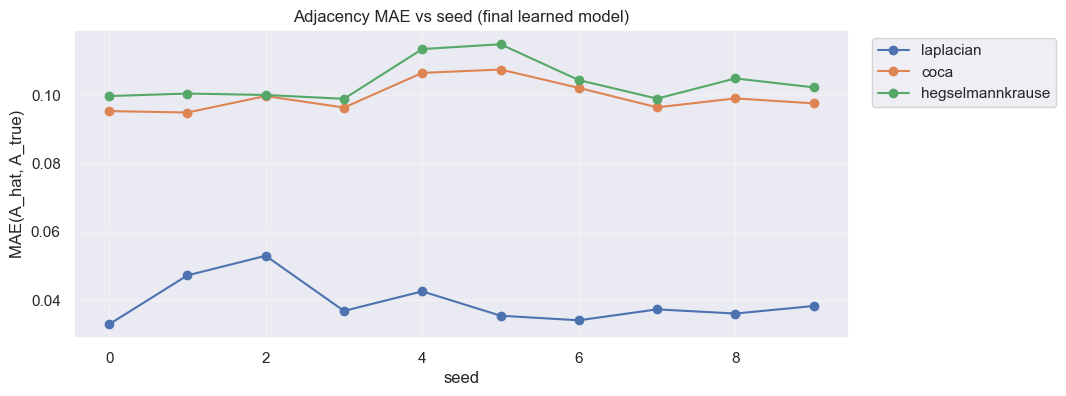

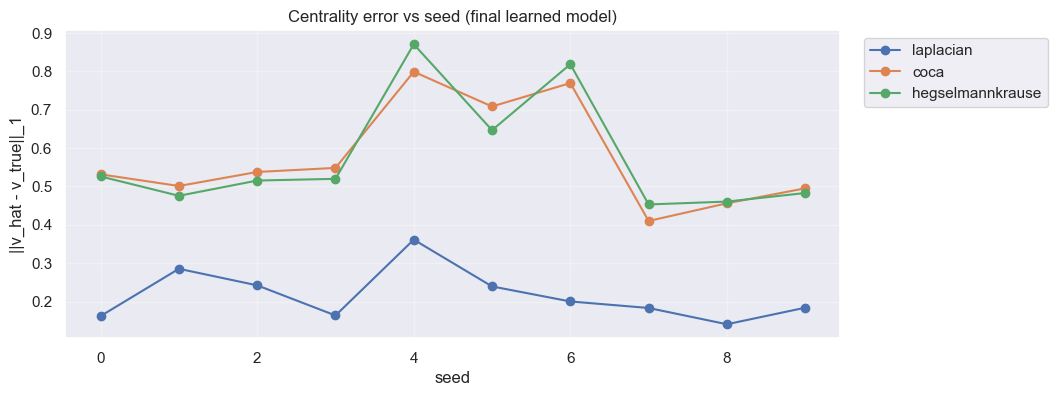

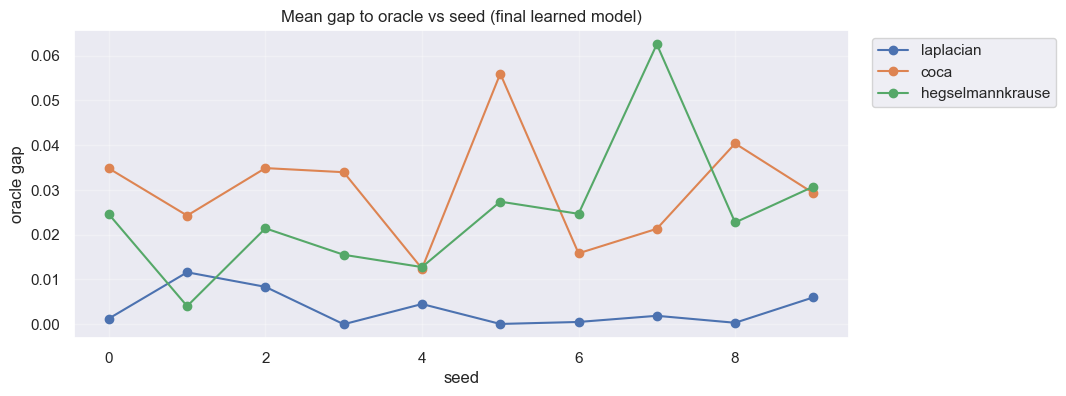

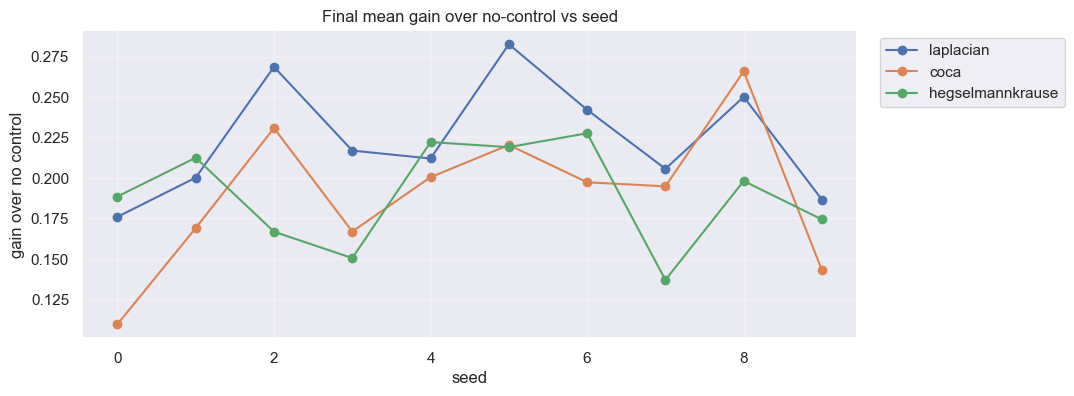

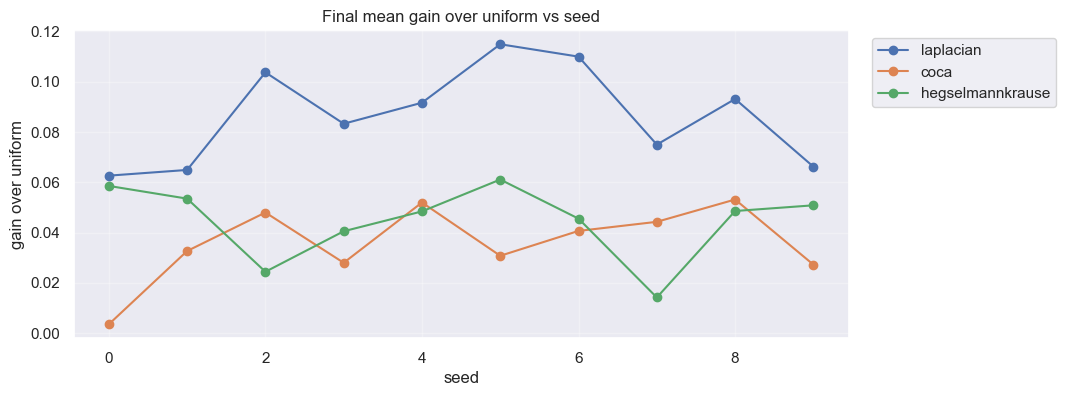

Cached final models are available as final_models_by_dyn_seed[dynamics][seed].
Cached final artifacts are available as final_artifacts_by_dyn_seed[dynamics][seed].
Cached training initial states are available as train_x0s_by_dyn_seed[dynamics][seed].


In [6]:
# =========================================================
# Main experiment across propagation methods
# Learn from many one-campaign no-control rollouts.
# Evaluate final learned model under control.
# Cache ONLY the final resources needed downstream.
# =========================================================

final_models_by_dyn_seed = {}
final_metrics_by_dyn_seed = {}
final_artifacts_by_dyn_seed = {}
train_x0s_by_dyn_seed = {}
df_final_by_dyn = {}

dfs_final = []

for dyn in DYNAMICS_LIST:
    print(f"=== Running {dyn} | learn from no-control single-campaign random inits ===")
    df_all, seed_cache = run_multi_seed_nocontrol_singlecampaign_experiment_dynamics(
        seeds=SEEDS,
        repeats_per_seed=NUM_REPEATS,
        dynamics_model=dyn,
        init_mode=INIT_MODE,
        learn_num_campaigns=LEARN_NUM_CAMPAIGNS,
        eval_num_campaigns=EVAL_NUM_CAMPAIGNS,
        B_campaign=B_CAMPAIGN,
        suppress_fit_logs=True,
        return_artifacts=True,
        identifier_kwargs=IDENTIFIER_KW,
        **FIT_BY_DYNAMICS[dyn],
    )

    final_models_by_dyn_seed[dyn] = {}
    final_metrics_by_dyn_seed[dyn] = {}
    final_artifacts_by_dyn_seed[dyn] = {}
    train_x0s_by_dyn_seed[dyn] = {}

    for seed in SEEDS:
        seed_out = seed_cache[int(seed)]
        final_models_by_dyn_seed[dyn][int(seed)] = seed_out["model_final"]
        final_metrics_by_dyn_seed[dyn][int(seed)] = seed_out["final_row"]
        final_artifacts_by_dyn_seed[dyn][int(seed)] = seed_out["final_artifact"]
        train_x0s_by_dyn_seed[dyn][int(seed)] = seed_out["train_x0s"]

    # We only keep the final repeat per seed for downstream summaries.
    df_final = (
        df_all.sort_values(["seed", "repeat"])
        .groupby("seed", as_index=False, group_keys=False)
        .tail(1)
        .reset_index(drop=True)
    )
    df_final_by_dyn[dyn] = df_final
    dfs_final.append(df_final)

    # Drop bulky intermediate objects as soon as possible.
    del seed_cache
    del df_all

df = pd.concat(dfs_final, axis=0).reset_index(drop=True)
display(df)

print("=== Aggregate by dynamics (final repeat only) ===")
cols = [
    "repeat",
    "train_pairs_total",
    "v_L1_final",
    "A_MAE_final",
    "mean_gap_to_oracle_end",
    "mean_gain_vs_noc_end",
    "mean_gain_vs_uniform_end",
    "vx_gap_to_oracle_end",
    "time_fit_inner",
]
display(df.groupby("dynamics")[cols].describe().T)

for metric, ylabel, title in [
    ("A_MAE_final", "MAE(A_hat, A_true)", "Adjacency MAE vs seed (final learned model)"),
    ("v_L1_final", "||v_hat - v_true||_1", "Centrality error vs seed (final learned model)"),
    ("mean_gap_to_oracle_end", "oracle gap", "Mean gap to oracle vs seed (final learned model)"),
    ("mean_gain_vs_noc_end", "gain over no control", "Final mean gain over no-control vs seed"),
    ("mean_gain_vs_uniform_end", "gain over uniform", "Final mean gain over uniform vs seed"),
]:
    plt.figure(figsize=(10, 4))
    for dyn in DYNAMICS_LIST:
        sub = df[df["dynamics"] == dyn].sort_values("seed")
        plt.plot(sub["seed"], sub[metric], marker="o", label=dyn)
    plt.xlabel("seed")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

print("Cached final models are available as final_models_by_dyn_seed[dynamics][seed].")
print("Cached final artifacts are available as final_artifacts_by_dyn_seed[dynamics][seed].")
print("Cached training initial states are available as train_x0s_by_dyn_seed[dynamics][seed].")


In [7]:
# =========================================================
# Single-seed detailed runs for ALL dynamics
# Reuse the cached FINAL outputs from the main experiment cell.
# Uses local variables so notebook-wide config is not overwritten.
# =========================================================

seed_to_plot = int(globals().get("SEED_TO_PLOT"))
num_repeats_local = int(globals().get("NUM_REPEATS"))
dynamics_list_local = list(globals().get("DYNAMICS_LIST"))

outs_by_dyn = {}
metrics_by_dyn = {}
art_by_dyn = {}
model_by_dyn = {}

for dyn_name in dynamics_list_local:
    print("\n" + "=" * 80)
    print(f"=== DYNAMICS: {dyn_name} | SEED {seed_to_plot} ===")
    print("=" * 80)

    metrics = final_metrics_by_dyn_seed[dyn_name][int(seed_to_plot)]
    art = final_artifacts_by_dyn_seed[dyn_name][int(seed_to_plot)]
    model = final_models_by_dyn_seed[dyn_name][int(seed_to_plot)]
    train_x0s = train_x0s_by_dyn_seed[dyn_name][int(seed_to_plot)]

    outs_by_dyn[dyn_name] = {
        "train_x0s": train_x0s,
        "x0_eval": art["x0_eval"],
    }
    metrics_by_dyn[dyn_name] = metrics
    art_by_dyn[dyn_name] = art
    model_by_dyn[dyn_name] = model

    print(f"=== FINAL REPEAT {metrics['repeat'] + 1}/{num_repeats_local} ===")
    print(f"train_pairs_total: {metrics['train_pairs_total']}")
    print("=== METRICS ===")
    for k, v in metrics.items():
        print(f"{k}: {v}")



=== DYNAMICS: laplacian | SEED 3 ===
=== FINAL REPEAT 100/100 ===
train_pairs_total: 400
=== METRICS ===
seed: 3
repeat: 99
repeat_seed: 1000003
dynamics: laplacian
init_mode: uniform
learn_num_campaigns: 1
eval_num_campaigns: 5
N: 15
train_pairs_total: 400
v_L1_final: 0.16379256489992083
A_Fro_final: 0.8442606195943095
A_MAE_final: 0.03678529285552306
mean_oracle_end: 0.7588969121419051
mean_learn_end: 0.7588969121355557
mean_noc_end: 0.5419949435982832
mean_uniform_end: 0.6756199355335678
mean_flat_rank_end: 0.6940502706884915
mean_gap_to_oracle_end: 6.349476500133733e-12
mean_gain_vs_noc_end: 0.2169019685372725
mean_gain_vs_uniform_end: 0.08327697660198785
mean_gain_vs_flat_rank_end: 0.0648466414470642
oracle_gain_vs_flat_rank_end: 0.06484664145341368
train_identity_mae: 0.049872104881348356
train_model_one_step_mae: 0.0061160363256931305
train_model_mae_over_identity: 0.12263441337083937
action_l1_vs_oracle_avg: 2.384185791015625e-08
action_l1_vs_flat_rank_avg: 1.2000000119209289



--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: laplacian ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

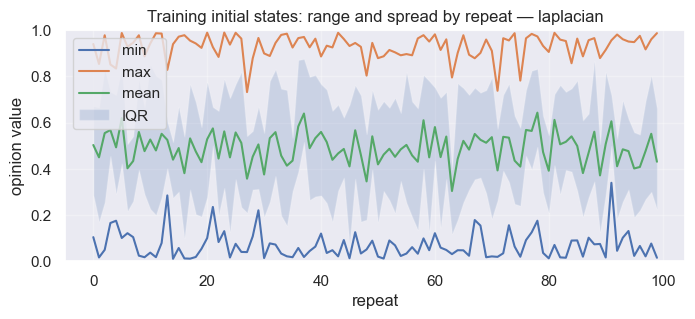

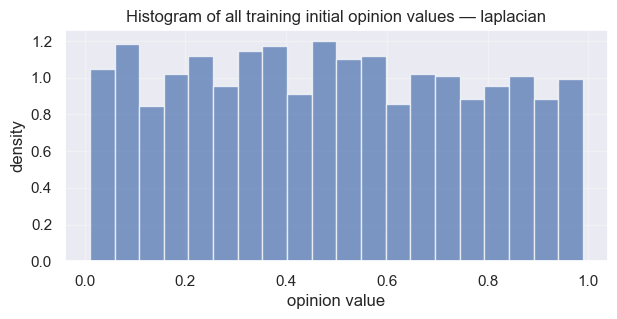

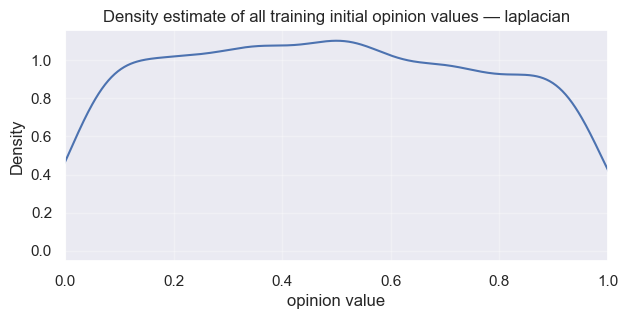

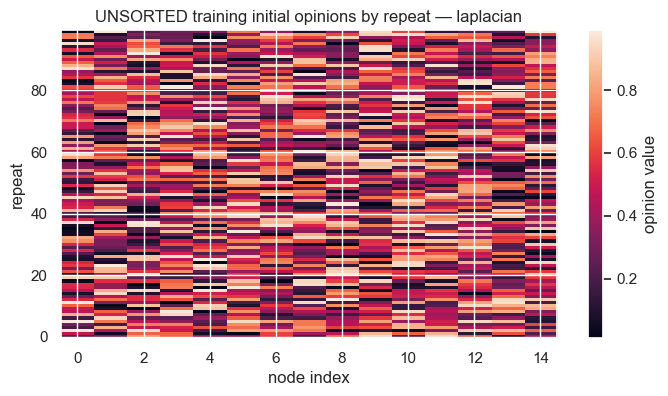

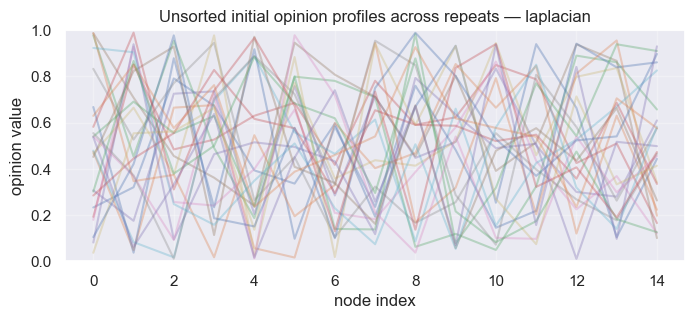


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: coca ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

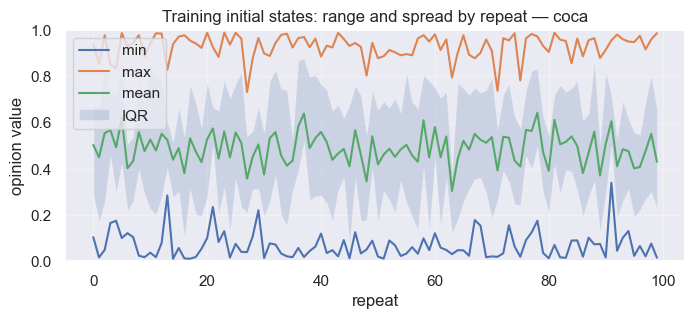

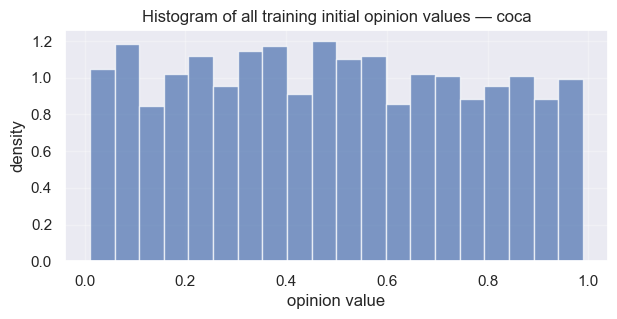

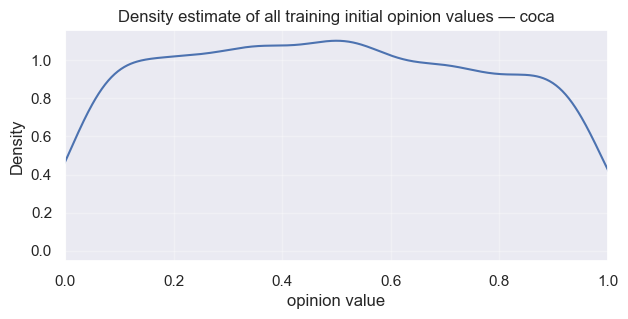

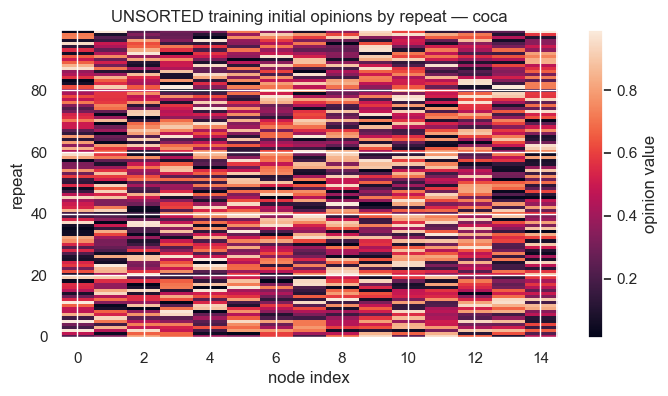

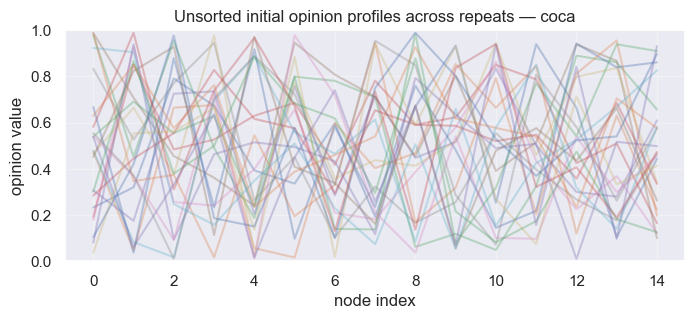


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: hegselmannkrause ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

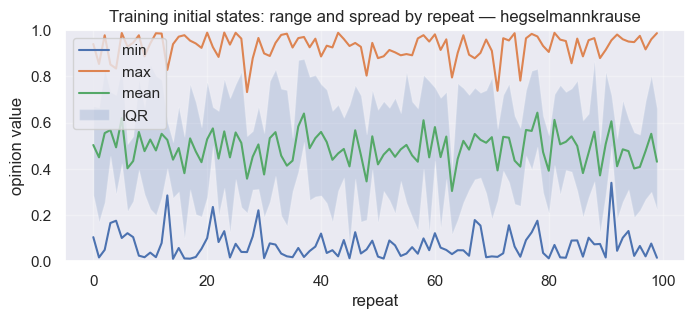

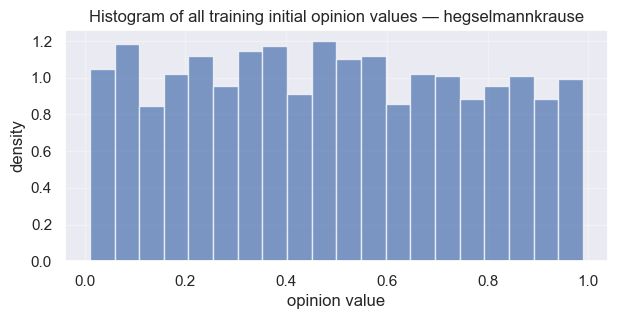

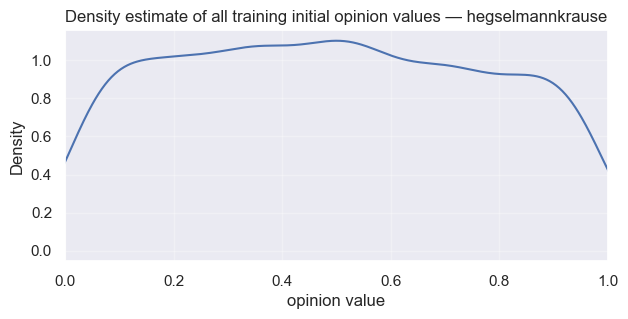

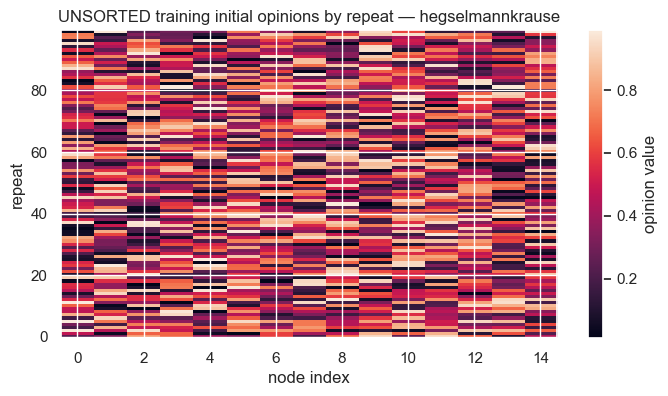

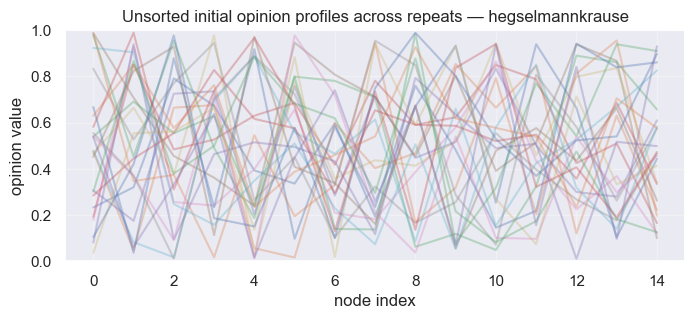

In [8]:
# =========================================================
# Sanity check: inspect the training initial states
# NOTE: uses the globally configured INIT_MODE and the cached train_x0s for the selected seed.
# =========================================================

for DYNAMICS in list(art_by_dyn.keys()):
    out = outs_by_dyn[DYNAMICS]
    all_x0_train = np.asarray(out["train_x0s"], dtype=float)
    summary_df = summarize_training_inits(all_x0_train)

    print("\n" + "-" * 80)
    print(f"=== TRAINING-INIT SANITY: {DYNAMICS} ===")
    print("-" * 80)
    display(summary_df.describe().T)

    flat = all_x0_train.ravel()
    print("Overall value summary:")
    display(pd.Series(flat).describe())

    plt.figure(figsize=(8, 3))
    plt.plot(summary_df["repeat"], summary_df["min"], label="min")
    plt.plot(summary_df["repeat"], summary_df["max"], label="max")
    plt.plot(summary_df["repeat"], summary_df["mean"], label="mean")
    plt.fill_between(summary_df["repeat"], summary_df["q25"], summary_df["q75"], alpha=0.2, label="IQR")
    plt.title(f"Training initial states: range and spread by repeat — {DYNAMICS}")
    plt.xlabel("repeat")
    plt.ylabel("opinion value")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.hist(flat, bins=20, density=True, alpha=0.7)
    plt.title(f"Histogram of all training initial opinion values — {DYNAMICS}")
    plt.xlabel("opinion value")
    plt.ylabel("density")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 3))
    pd.Series(flat).plot(kind="density")
    plt.title(f"Density estimate of all training initial opinion values — {DYNAMICS}")
    plt.xlabel("opinion value")
    plt.xlim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.imshow(all_x0_train, aspect="auto", origin="lower")
    plt.colorbar(label="opinion value")
    plt.title(f"UNSORTED training initial opinions by repeat — {DYNAMICS}")
    plt.xlabel("node index")
    plt.ylabel("repeat")
    plt.show()

    plt.figure(figsize=(8, 3))
    for r in range(min(all_x0_train.shape[0], 25)):
        plt.plot(all_x0_train[r], alpha=0.35)
    plt.title(f"Unsorted initial opinion profiles across repeats — {DYNAMICS}")
    plt.xlabel("node index")
    plt.ylabel("opinion value")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()


=== DETAILED ANALYSIS: laplacian | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999998901039362
row_sum_mean: 0.9999999976328885
row_sum_max: 1.0000001061707735
asym: 0.7906606433078583
edges: 210
sink_sizes: [15]
has_singleton_sink: False


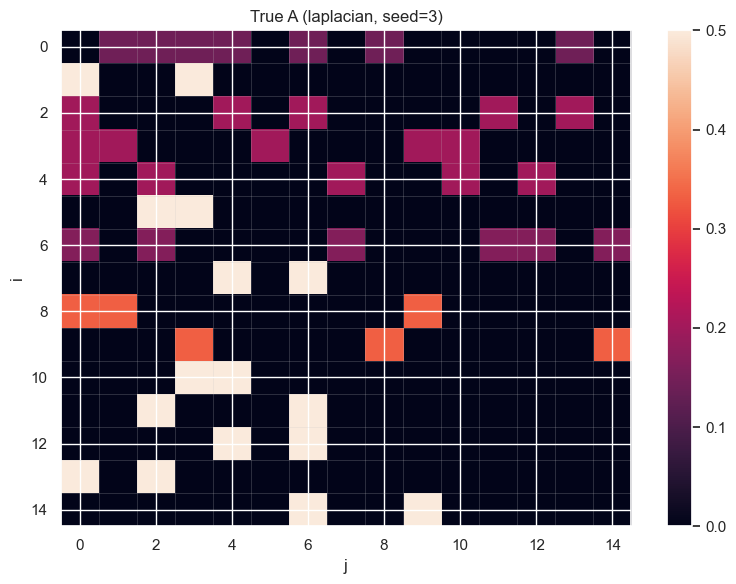

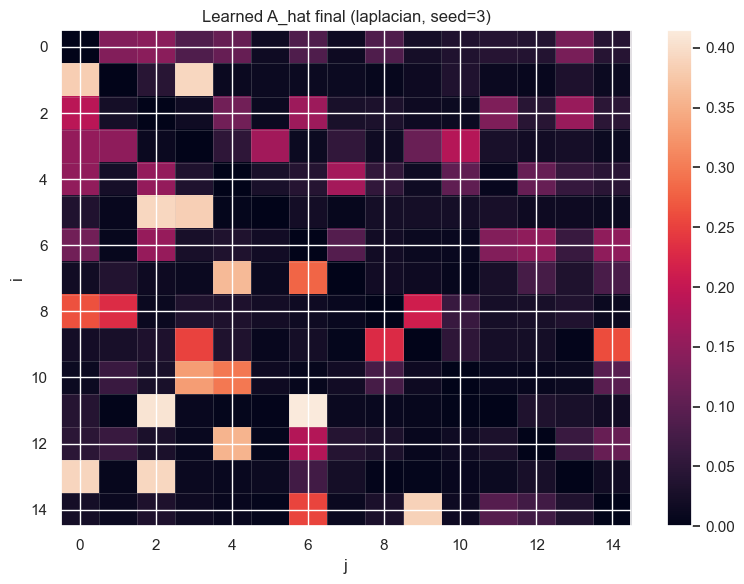


=== FAIRNESS / TIME GRID CHECK ===
EVAL_ZERO_FIRST_CAMPAIGN: False
dt/t_s=0.5, t_campaign=2.0, campaigns=5
learned: T[0], T[-1], monotone: 0.0 10.0 True
oracle : T[0], T[-1], monotone: 0.0 10.0 True
campaign-0 action sums: learned= 1.0 oracle= 1.0 flat-rank= 1.0 uniform= 0.9999999999999999 nocontrol= 0.0
campaign-0 action L_inf learned-oracle: 1.4901161193847656e-08
campaign-0 action L_inf learned-flat-rank: 1.4901161193847656e-08


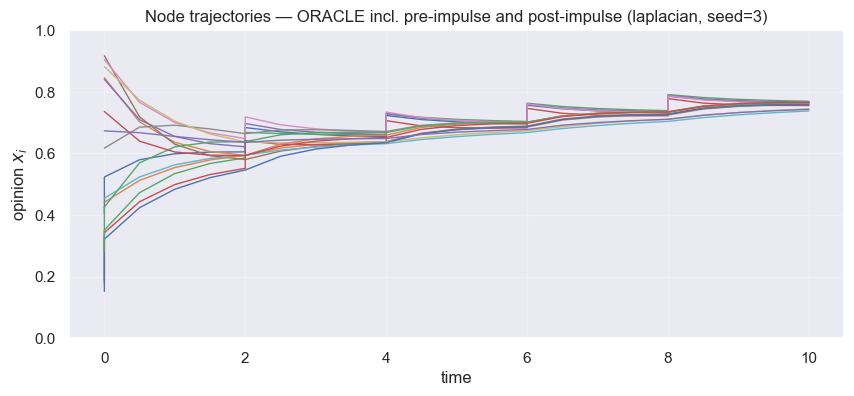

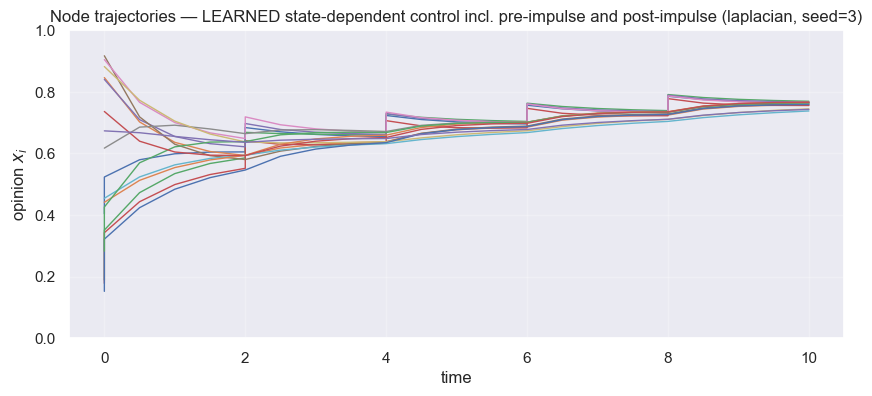


=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.16379256489992083
L1(v_eff at campaign 0 - v_true): 0.160364038677215


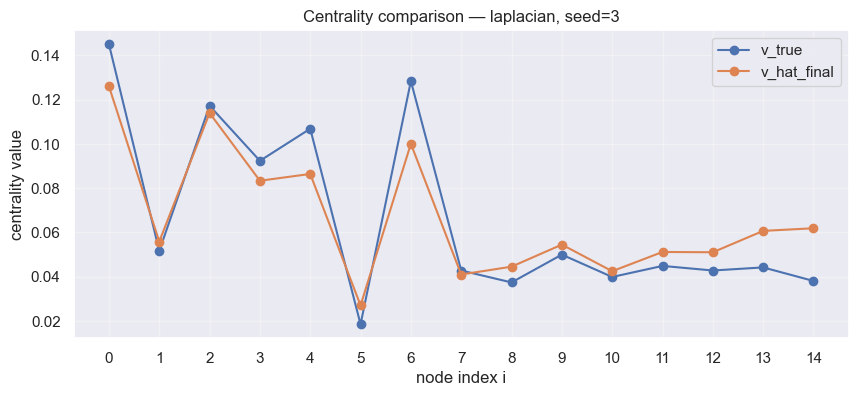

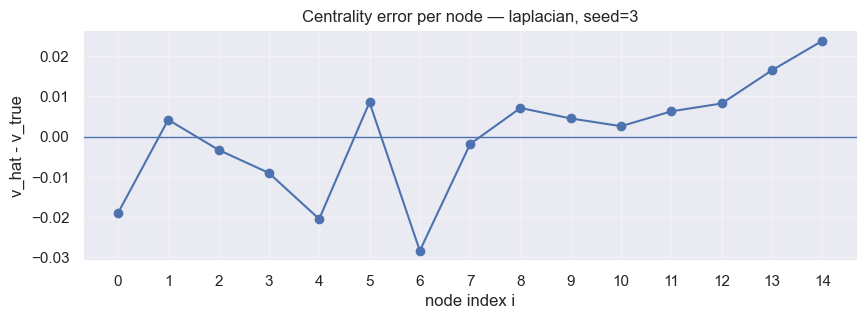

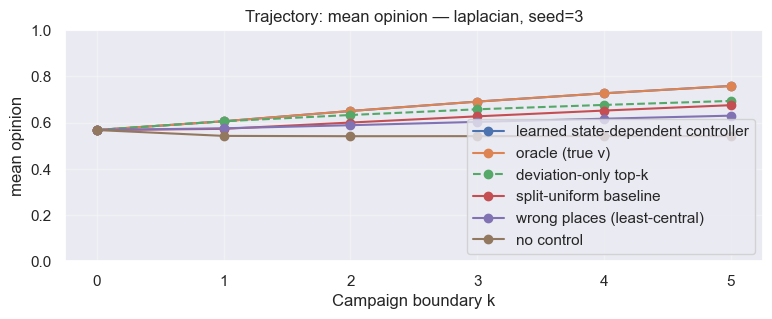


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 2.150702838044083e-09
learned states[1] vs nocontrol states[1] L_inf: 0.09078837150428198
learned final mean vs split-uniform final mean: 0.08327697660198785
learned final mean vs deviation-only top-k final mean: 0.0648466414470642
oracle final mean vs deviation-only top-k final mean: 0.06484664145341368

=== DETAILED ANALYSIS: coca | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED 

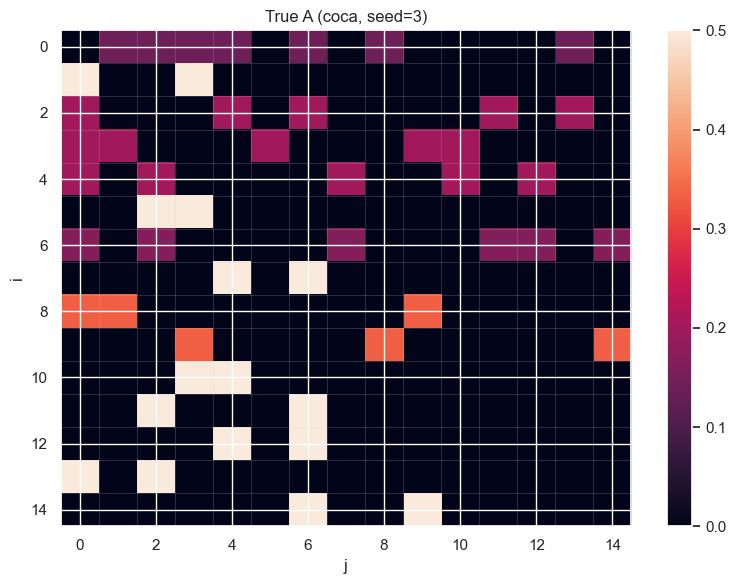

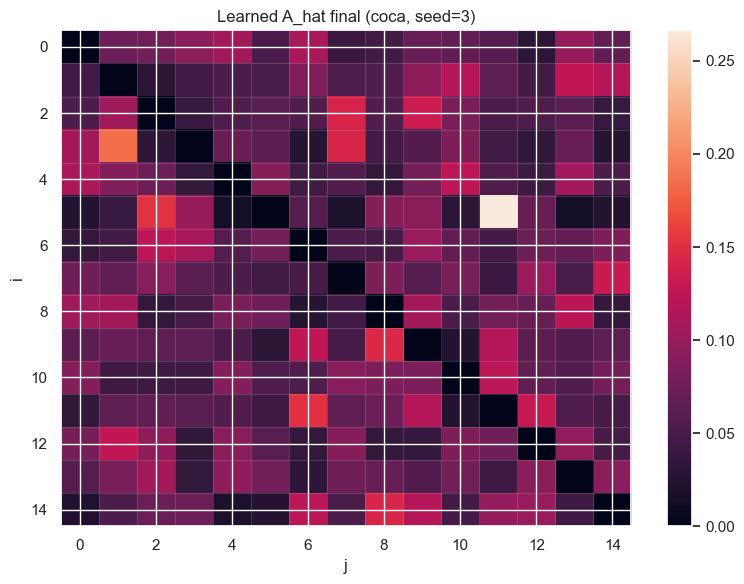


=== FAIRNESS / TIME GRID CHECK ===
EVAL_ZERO_FIRST_CAMPAIGN: False
dt/t_s=0.5, t_campaign=2.0, campaigns=5
learned: T[0], T[-1], monotone: 0.0 10.0 True
oracle : T[0], T[-1], monotone: 0.0 10.0 True
campaign-0 action sums: learned= 1.0 oracle= 1.0 flat-rank= 1.0 uniform= 0.9999999999999999 nocontrol= 0.0
campaign-0 action L_inf learned-oracle: 0.20000000298023224
campaign-0 action L_inf learned-flat-rank: 0.19999998807907104


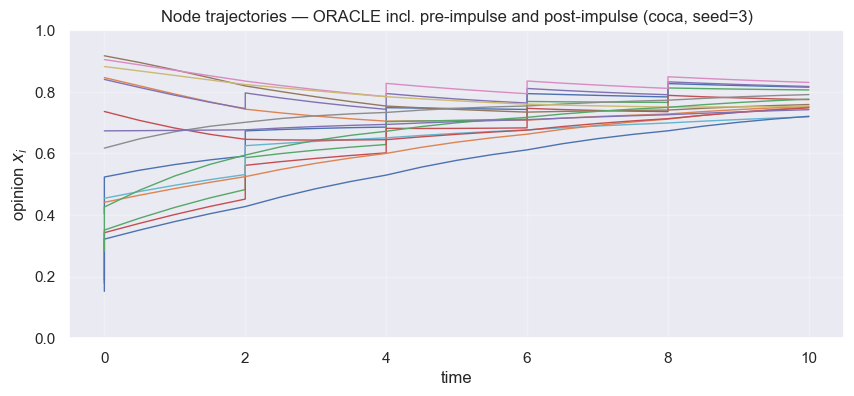

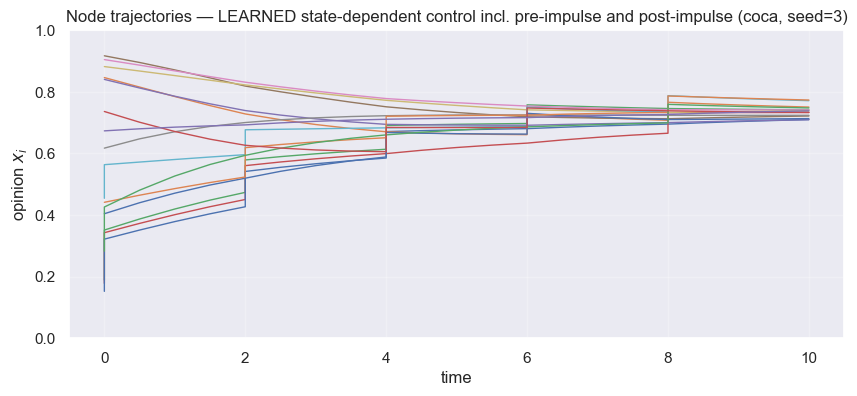


=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.5482763238628864
L1(v_eff at campaign 0 - v_true): 0.539236649908638


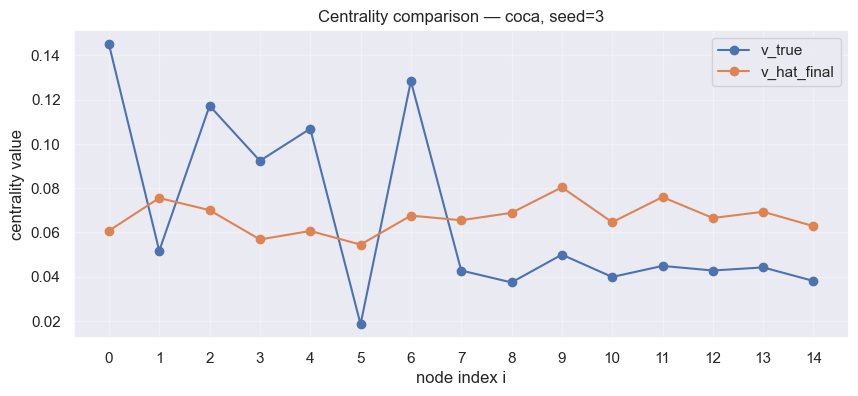

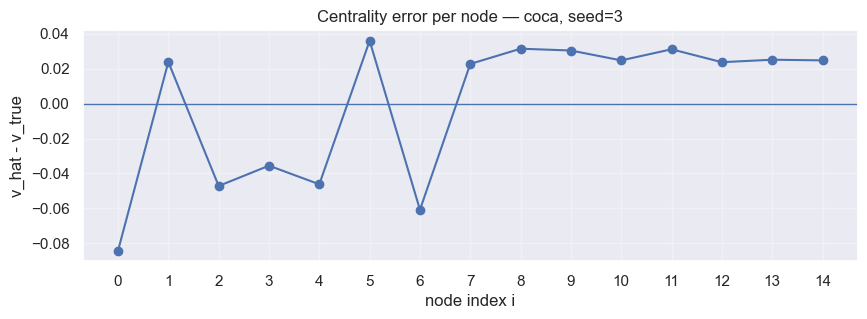

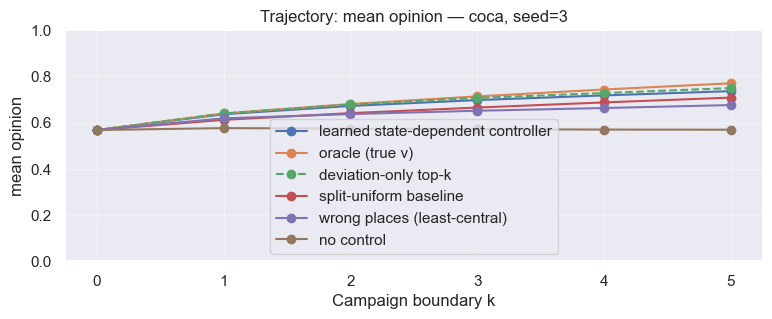


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.07195279123376896
learned states[1] vs nocontrol states[1] L_inf: 0.179355573260665
learned final mean vs split-uniform final mean: 0.027981315854974098
learned final mean vs deviation-only top-k final mean: -0.013205720462617587
oracle final mean vs deviation-only top-k final mean: 0.020768538240944268

=== DETAILED ANALYSIS: hegselmannkrause | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SAN

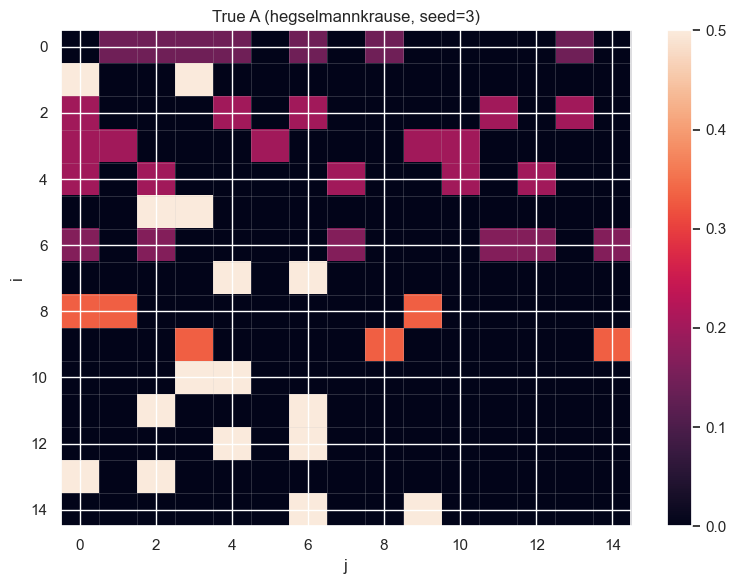

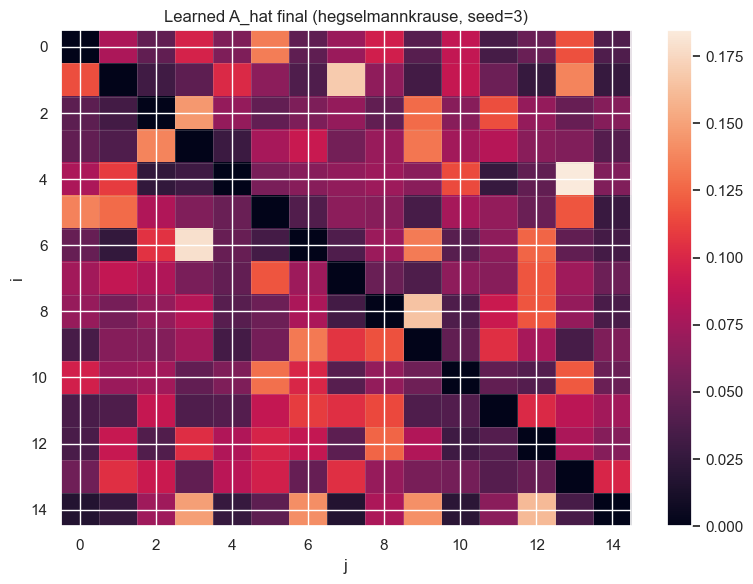


=== FAIRNESS / TIME GRID CHECK ===
EVAL_ZERO_FIRST_CAMPAIGN: False
dt/t_s=0.5, t_campaign=2.0, campaigns=5
learned: T[0], T[-1], monotone: 0.0 10.0 True
oracle : T[0], T[-1], monotone: 0.0 10.0 True
campaign-0 action sums: learned= 1.0 oracle= 1.0 flat-rank= 1.0 uniform= 0.9999999999999999 nocontrol= 0.0
campaign-0 action L_inf learned-oracle: 0.20000000298023224
campaign-0 action L_inf learned-flat-rank: 0.19999998807907104


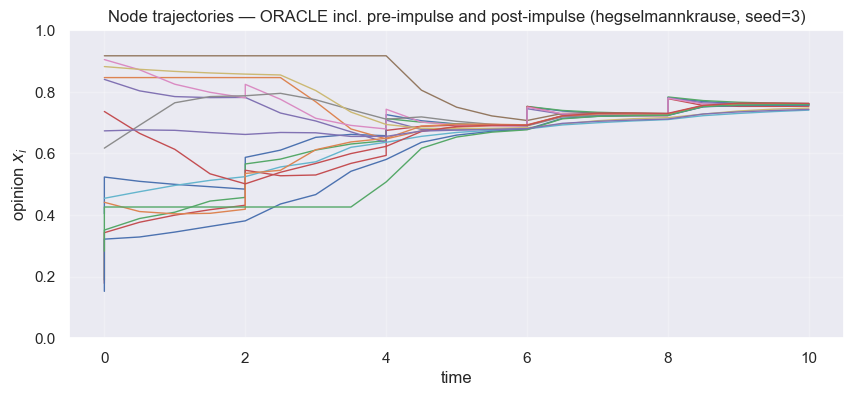

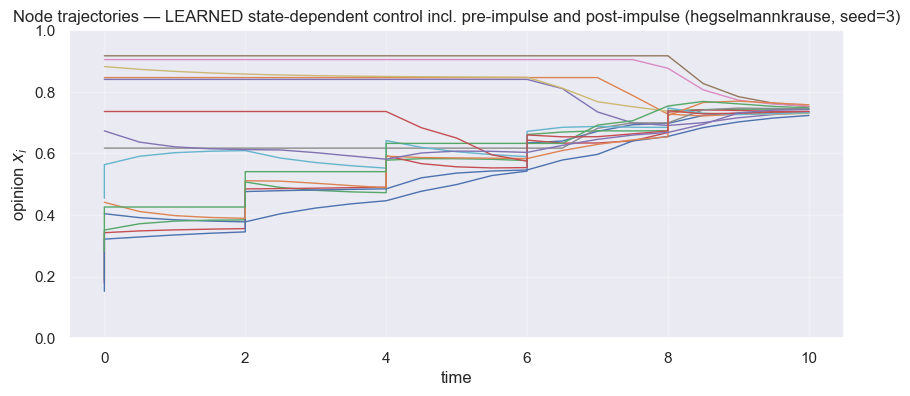


=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.5198180787642955
L1(v_eff at campaign 0 - v_true): 0.49085551634065505


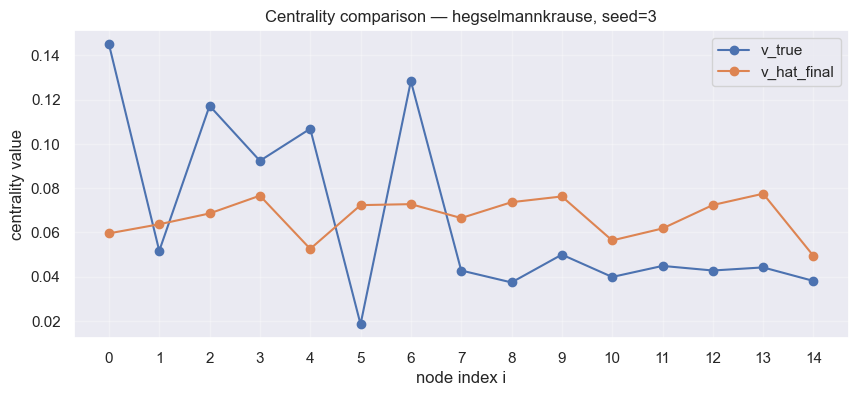

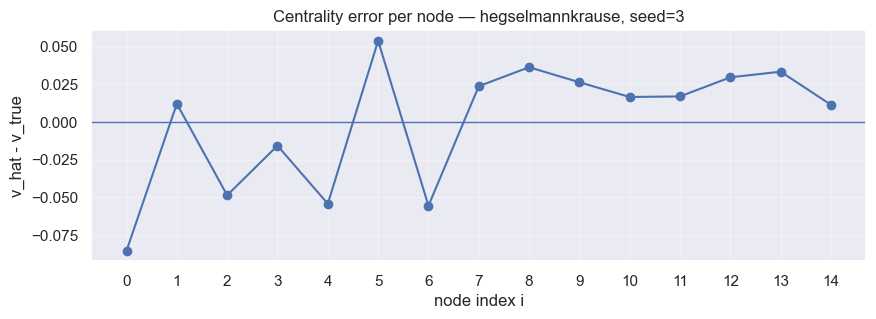

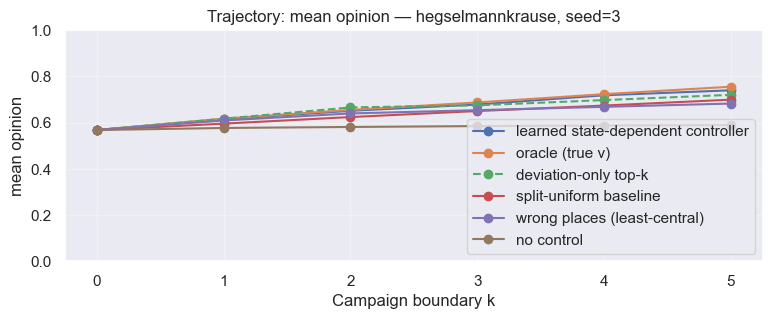


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.2349223886519104
learned states[1] vs nocontrol states[1] L_inf: 0.17027460907401681
learned final mean vs split-uniform final mean: 0.040523923217462454
learned final mean vs deviation-only top-k final mean: 0.01961117349405339
oracle final mean vs deviation-only top-k final mean: 0.03513603230648066


In [9]:
# =========================================================
# Detailed graph / rollout comparison for the final learned model
# Run for ALL dynamics, as in the previous repeated notebook.
# =========================================================
env_factory = EnvironmentFactory()

for DYNAMICS in list(art_by_dyn.keys()):
    art = art_by_dyn[DYNAMICS]

    A_true = np.asarray(art["A_true"], dtype=float)
    v_true = np.asarray(art["v_true"], dtype=float)
    A_hat_final = np.asarray(art["A_hat_final"], dtype=float)
    v_hat_final = np.asarray(art["v_hat_final"], dtype=float)

    x0_train = np.asarray(art["x0_train"], dtype=float)
    x0_eval = np.asarray(art["x0_eval"], dtype=float)

    states_learn = np.asarray(art["states_learn"], dtype=float)
    states_oracle = np.asarray(art["states_oracle"], dtype=float)
    states_noc = np.asarray(art["states_nocontrol_eval"], dtype=float)
    states_uniform = np.asarray(art["states_uniform_eval"], dtype=float)
    N = states_learn.shape[1]
    K_total = states_learn.shape[0] - 1

    print("\n" + "=" * 80)
    print(f"=== DETAILED ANALYSIS: {DYNAMICS} | SEED {seed_to_plot} ===")
    print("=" * 80)
    print("x0_train:", x0_train)
    print("x0_eval :", x0_eval)

    print("\n=== GRAPH SANITY (TRUE) ===")
    for k, v in graph_sanity(A_true).items():
        print(f"{k}: {v}")

    print("\n=== GRAPH SANITY (LEARNED FINAL) ===")
    for k, v in graph_sanity(A_hat_final).items():
        print(f"{k}: {v}")

    show_matrix_with_cell_grid(
        A_true,
        title=f"True A ({DYNAMICS}, seed={seed_to_plot})",
        grid_alpha=0.25,
        grid_lw=0.6,
    )
    show_matrix_with_cell_grid(
        A_hat_final,
        title=f"Learned A_hat final ({DYNAMICS}, seed={seed_to_plot})",
        grid_alpha=0.25,
        grid_lw=0.6,
    )

    env_template = make_env_with_dynamics(
        env_factory,
        seed=seed_to_plot,
        dynamics_model=DYNAMICS,
    )

    env_learn, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_or, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_nc, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_uni, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_flat, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )

    le_out = rollout_with_model_derived_control_intermediate(
        env_learn,
        model_by_dyn[DYNAMICS],
        x0_eval,
        K_total,
        B_CAMPAIGN,
        device="cpu",
    )
    or_out = rollout_with_v_intermediate(
        env_or, x0_eval, K_total, B_CAMPAIGN, v_true,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )
    nc_out = rollout_with_v_intermediate(
        env_nc, x0_eval, K_total, B_CAMPAIGN, None,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )
    uni_out = rollout_with_uniform_intermediate(env_uni, x0_eval, K_total, B_CAMPAIGN)
    v_flat = np.full(N, 1.0 / max(N, 1), dtype=float)
    flat_out = rollout_with_v_intermediate(
        env_flat, x0_eval, K_total, B_CAMPAIGN, v_flat,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )

    order = np.argsort(v_true)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(v_true) + 1)
    v_anti = 1.0 / ranks
    v_anti = v_anti / v_anti.sum()

    env_anti, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    anti_out = rollout_with_v_intermediate(
        env_anti, x0_eval, K_total, B_CAMPAIGN, v_anti,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )

    # Boundary-level states for checks and summary plots
    states_learn_eval = np.asarray(le_out["states"], dtype=float)
    states_or_eval = np.asarray(or_out["states"], dtype=float)
    states_nc_eval = np.asarray(nc_out["states"], dtype=float)
    states_anti_eval = np.asarray(anti_out["states"], dtype=float)
    states_uni_eval = np.asarray(uni_out["states"], dtype=float)
    states_flat_eval = np.asarray(flat_out["states"], dtype=float)

    dt = float(getattr(env_template, "t_s", 1.0))
    t_campaign = float(getattr(env_template, "t_campaign", dt))
    desired_opinion = float(getattr(env_template, "desired_opinion", 1.0))

    X_le, T_le = build_augmented_campaign_trajectory(
        states_learn_eval,
        np.asarray(le_out["actions"], dtype=float),
        le_out["intermediate_states_list"],
        desired_opinion=desired_opinion,
        dt=dt,
        t_campaign=t_campaign,
    )
    X_or, T_or = build_augmented_campaign_trajectory(
        states_or_eval,
        np.asarray(or_out["actions"], dtype=float),
        or_out["intermediate_states_list"],
        desired_opinion=desired_opinion,
        dt=dt,
        t_campaign=t_campaign,
    )

    print("\n=== FAIRNESS / TIME GRID CHECK ===")
    print("EVAL_ZERO_FIRST_CAMPAIGN:", EVAL_ZERO_FIRST_CAMPAIGN)
    print(f"dt/t_s={dt}, t_campaign={t_campaign}, campaigns={K_total}")
    print("learned: T[0], T[-1], monotone:", float(T_le[0]), float(T_le[-1]), bool(np.all(np.diff(T_le) >= -1e-9)))
    print("oracle : T[0], T[-1], monotone:", float(T_or[0]), float(T_or[-1]), bool(np.all(np.diff(T_or) >= -1e-9)))
    print("campaign-0 action sums:",
          "learned=", float(np.asarray(le_out["actions"])[0].sum()),
          "oracle=", float(np.asarray(or_out["actions"])[0].sum()),
          "flat-rank=", float(np.asarray(flat_out["actions"])[0].sum()),
          "uniform=", float(np.asarray(uni_out["actions"])[0].sum()),
          "nocontrol=", float(np.asarray(nc_out["actions"])[0].sum()))
    print("campaign-0 action L_inf learned-oracle:",
          float(np.max(np.abs(np.asarray(le_out["actions"])[0] - np.asarray(or_out["actions"])[0]))))
    print("campaign-0 action L_inf learned-flat-rank:",
          float(np.max(np.abs(np.asarray(le_out["actions"])[0] - np.asarray(flat_out["actions"])[0]))))

    plot_impulse_node_trajectories(
        X_or,
        T_or,
        title=f"Node trajectories — ORACLE incl. pre-impulse and post-impulse ({DYNAMICS}, seed={seed_to_plot})",
    )
    plot_impulse_node_trajectories(
        X_le,
        T_le,
        title=f"Node trajectories — LEARNED state-dependent control incl. pre-impulse and post-impulse ({DYNAMICS}, seed={seed_to_plot})",
    )

    print("\n=== INITIAL-STATE / IMPULSE CHECK ===")
    print("L_inf(common x0_eval - learned boundary state[0]):", float(np.max(np.abs(x0_eval - states_learn_eval[0]))))
    print("L_inf(common x0_eval - oracle boundary state[0]):", float(np.max(np.abs(x0_eval - states_or_eval[0]))))
    print("L_inf(learned boundary state[0] - oracle boundary state[0]):", float(np.max(np.abs(states_learn_eval[0] - states_or_eval[0]))))
    print("Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.")

    print("\n=== CENTRALITY COMPARISON (by node index) ===")
    print("L1(v_hat_final - v_true):", float(np.sum(np.abs(v_hat_final - v_true))))
    if art.get("learned_effective_centralities"):
        v_eff0 = np.asarray(art["learned_effective_centralities"][0], dtype=float)
        print("L1(v_eff at campaign 0 - v_true):", float(np.sum(np.abs(v_eff0 - v_true))))

    idx = np.arange(N)
    diff = v_hat_final - v_true

    plt.figure(figsize=(10, 4))
    plt.plot(idx, v_true, marker="o", label="v_true")
    plt.plot(idx, v_hat_final, marker="o", label="v_hat_final")
    plt.xlabel("node index i")
    plt.ylabel("centrality value")
    plt.title(f"Centrality comparison — {DYNAMICS}, seed={seed_to_plot}")
    plt.xticks(idx)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.axhline(0.0, linewidth=1)
    plt.plot(idx, diff, marker="o")
    plt.xlabel("node index i")
    plt.ylabel("v_hat - v_true")
    plt.title(f"Centrality error per node — {DYNAMICS}, seed={seed_to_plot}")
    plt.xticks(idx)
    plt.grid(True, alpha=0.3)
    plt.show()

    mean_learn = states_learn_eval.mean(axis=1)
    mean_or = states_or_eval.mean(axis=1)
    mean_nc = states_nc_eval.mean(axis=1)
    mean_uni = states_uni_eval.mean(axis=1)
    mean_flat = states_flat_eval.mean(axis=1)
    mean_anti = states_anti_eval.mean(axis=1)

    plt.figure(figsize=(9, 3))
    plt.plot(mean_learn, marker="o", label="learned state-dependent controller")
    plt.plot(mean_or, marker="o", label="oracle (true v)")
    plt.plot(mean_flat, marker="o", linestyle="--", label="deviation-only top-k")
    plt.plot(mean_uni, marker="o", label="split-uniform baseline")
    plt.plot(mean_anti, marker="o", label="wrong places (least-central)")
    plt.plot(mean_nc, marker="o", label="no control")
    plt.xlabel("Campaign boundary k")
    plt.ylabel("mean opinion")
    plt.title(f"Trajectory: mean opinion — {DYNAMICS}, seed={seed_to_plot}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(0, 1)
    plt.show()

    print("\n=== CAMPAIGN-0 OVERLAP CHECK ===")
    print(
        "learned states[1] vs oracle states[1] L_inf:",
        float(np.max(np.abs(states_learn_eval[1] - states_or_eval[1]))),
    )
    print(
        "learned states[1] vs nocontrol states[1] L_inf:",
        float(np.max(np.abs(states_learn_eval[1] - states_nc_eval[1]))),
    )

    print("learned final mean vs split-uniform final mean:",
          float(mean_learn[-1] - mean_uni[-1]))
    print("learned final mean vs deviation-only top-k final mean:",
          float(mean_learn[-1] - mean_flat[-1]))
    print("oracle final mean vs deviation-only top-k final mean:",
          float(mean_or[-1] - mean_flat[-1]))
